# Understanding parallelization of the task-based $GW$ calculations
By: Martí Raya Moreno, Hannah Kleine, and Sven Lubeck

This tutorial aims to instruct the reader on how to efficiently parallelize a task-based GW calculation on an HPC system. Note that this tutorial is intended for guidance only and does not execute any calculations. Running the presented example would require access to an HPC system.

# Small recap on the task-based workflow for $GW$ Calculations

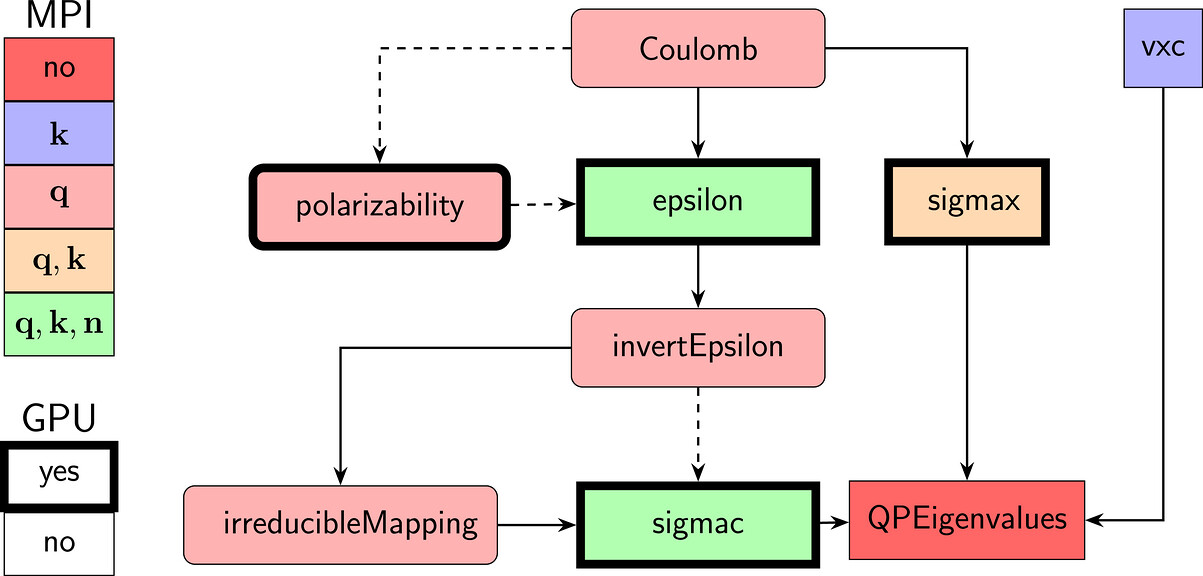

*Workflow diagram illustrating the tasks required for a GW calculation. Color coding denotes MPI parallelization over **q** points, **k** points, and unoccupied states (n). Tasks with thick outlines support GPU acceleration. Solid arrows represent the preferred workflow, whereas dashed arrows indicate non-recommended alternatives. The `Coulomb` task evaluates the bare Coulomb interaction, and `vxc` provides the diagonal matrix elements of the exchange-correlation potential. The `polarizability` task constructs the irreducible polarizability, which is then used by `epsilon` to form the dielectric matrix within the RPA. Its inversion is carried out by `invertEpsilon`, followed by `irreducibleMapping`, which exploits crystal symmetries to reconstruct the inverse dielectric matrix over the full BZ from the irreducible one in case crystal symmetry was used in `epsilon`. The self-energy is separated into exchange and correlation contributions, evaluated by `sigmax` and `sigmac`, respectively. Finally, `QPEigenvalues` combines these components to obtain the QP energies.*


As explained in previous tutorials,the latest implementation of the $GW$ method is a **task-based workflow**, where each computational step is treated as an independent task. This modular approach allows **parallelization over multiple dimensions**—$\mathbf{k}$ points, $\mathbf{q}$ points, and bands—and supports **GPU acceleration** for the most compute-intensive operations. By organizing $GW$ as a sequence of tasks, the workflow achieves strong and weak scaling across modern HPC architectures, enabling large-scale, high-precision calculations. We note that the preferred workflow is indicated by solid lines and exploits crystal symmetry to reduce the computational cost by limiting the calculation of the dielectric matrix to the irreducible wedge.

## Overview of the tasks:

1. **Coulomb**  
   - Evaluates the **bare Coulomb interaction** between electrons.  
   - Parallelized over **$\mathbf{q}$ points**.  
   - Supports GPU acceleration for the diagonalization of the bare Coulomb matrix.

2. **vxc**  
   - Computes the **diagonal matrix elements of the exchange-correlation potential** from the reference DFT calculation.  
   - Parallelized over **$\mathbf{k}$ points**.  
   - Lightweight task, usually CPU-bound.

3. **Polarizability**  
   - Constructs the **irreducible polarizability** by summing products of occupied and unoccupied states.  
   - Parallelized over **$\mathbf{q}$ points**.  
   - GPU acceleration is applied to dense matrix multiplications and loop-intensive operations.

4. **Epsilon**  
   - Forms the **dielectric matrix** in the Random Phase Approximation (RPA) using the polarizability.  
   - Parallelized over **$\mathbf{k}$ points, $\mathbf{q}$ points, unoccopied bands**.  
   - Matrix inversion steps can leverage GPU libraries.

5. **invertEpsilon**  
   - Computes the **inverse of the dielectric matrix**, required to screen the Coulomb interaction.  
   - Parallelized over **$\mathbf{q}$ points**.  
   - GPU acceleration used for linear algebra operations.

6. **irreducibleMapping**  
   - Exploits **crystal symmetries** to reconstruct the full inverse dielectric matrix in the Brillouin zone from the irreducible set.  
   - Parallelized over **$\mathbf{q}$ points**.  

7. **sigmax (Exchange Self-Energy)**  
   - Computes the **exchange part of the self-energy**, involving sums over occupied states.  
   - Parallelized over **$\mathbf{k}$ and $\mathbf{q}$-points**.  
   - GPU acceleration is applied to dense matrix multiplications and loop-intensive operations.

8. **sigmac (Correlation Self-Energy)**  
   - Computes the **correlation part of the self-energy**, involving sums over unoccupied states and frequency integration.  
   - Parallelized over **$\mathbf{k}$ points, $\mathbf{q}$ points, unoccopied bands**.  
   - GPU acceleration is applied to dense matrix multiplications and loop-intensive operations.

9. **QPEigenvalues**  
   - Combines the exchange and correlation contributions to compute **quasiparticle (QP) energies** using the linearized QP equation.  
   - Lightweight: not parallelized, can be run in serial.

# Running a GW Calculation in HPC: Dry‑Run Stage

A GW calculation in `exciting` should begin with a **dry run**. This step determines the number of irreducible q-points, verifies the symmetry settings, and reports memory requirements and parallelization information. It does not compute the GW quantities yet (apart from the non-self-consistent Kohn–Sham calculation); instead, it only prepares and validates the workflow.

---

## 1. Performing the Dry Run

To activate the dry‑run mode, include a `<taskGroup>` block inside the `<gw>` element:

```xml
<taskGroup outputFormat="binary" dryRun="true">
    <epsilon usingIrreducibleWedge="true" MPIDomainsQpoints="24" MPIDomainsKpoints="8">
        <qpoints qi="1" qf="-1"/>
    </epsilon>
</taskGroup>
```

Key points:

- `dryRun="true"` enables **dry-run mode**, in which the code only sets up and analyzes the calculation without executing the expensive numerical steps. This is useful for checking inputs and parallelization layouts.

- `usingIrreducibleWedge="true"` activates **symmetry reduction**, so that only the irreducible wedge of the Brillouin zone is considered, significantly reducing computational cost in cases with crystal symmetry.

- `MPIDomainsQpoints="24"` and `MPIDomainsKpoints="8"` define the **MPI parallelization hierarchy**.  
  Specifically, the calculation is divided into:
  - 24 MPI groups over **q-points**, and  
  - 8 MPI subgroups over **k-points** within each q-point group.  

  If `N` is the total number of MPI processes, then each subgroup uses  
  `N / (24 × 8)` MPI processes to parallelize over the **empty (unoccupied) states**.

- `<qpoints qi="1" qf="-1"/>` instructs the code to **loop over all q-points** in the predefined q-point grid, from the first to the last index.

---

### a. Example Input File

```xml
<input>
  <title>Ga2O3</title>
  <structure speciespath=".">
    <crystal>
      <basevect>   2.882457027       11.61489328       0.000000000</basevect>
      <basevect>  -2.882457027       11.61489328       0.000000000</basevect>
      <basevect>   0.000000000       2.600503369       10.67028355</basevect>
    </crystal>
    <species speciesfile="Ga.xml" rmt="1.7500">
      <atom coord="0.0000000000      0.0000000000      0.0000000000"/>
      <atom coord="0.6822620800      0.6822620800      0.6280570400"/>
      <atom coord="0.2511389000      0.2511389000      0.1090277600"/>
      <atom coord="0.4311231800      0.4311231800      0.5190292800"/>
    </species>
    <species speciesfile="O.xml" rmt="1.5000">
      <atom coord="0.1679453600      0.1679453600      0.8772238900"/>
      <atom coord="0.5143167200      0.5143167200      0.7508331500"/>
      <atom coord="0.1760095100      0.1760095100      0.4228546600"/>
      <atom coord="0.5062525700      0.5062525700      0.2052023800"/>
      <atom coord="0.8449338000      0.8449338000      0.5701798300"/>
      <atom coord="0.8373282800      0.8373282800      0.0578772100"/>
    </species>
  </structure>

  <groundstate
      do="skip"
      ngridk="8 8 8"
      xctype="GGA_PBE_SOL"
      gmaxvr="25.0"
      lmaxvr="12"
      lmaxapw="12"
      lmaxmat="12"
      rgkmax="8"
      maxscl="50"
      nempty="10">
  </groundstate>

  <gw
      taskname="taskGroup"
      ngridq="4 4 4"
      nempty="1600"
      ibgw="1"
      nbgw="120"
      mblksiz="400"
      GBatchCount="25"
      skipgnd="false"
      qdepw="sum"
      coreflag="all">

      <taskGroup outputFormat="binary" dryRun="true">
        <epsilon usingIrreducibleWedge="true" MPIDomainsQpoints="24" MPIDomainsKpoints="8">
          <qpoints qi="1" qf="-1"/>
        </epsilon>
      </taskGroup>

      <mixbasis
         lmaxmb="4"
         epsmb="1.d-4"
         gmb="1.0">
      </mixbasis>

      <barecoul
          pwm="2.0d0"
          barcevtol="0.1d0">
      </barecoul>

      <scrcoul averaging="anisotropic"/>

      <freqgrid nomeg="32"></freqgrid>

  </gw>
</input>
```

---

### b. NSCF Run for KS States

As previously noted, the $GW$ dry run first performs a **non-self-consistent (NSCF) calculation**, which generates the **Kohn–Sham (KS) eigenvalues and eigenvectors** on the selected k-point mesh. The parameter `ngridq` defines both the q- and k-point grid used for the $GW$ workflow, and in our case corresponds to `ngridq="4 4 4"`. The calculation also includes the number of unoccupied states specified by `nempty`, which determines the range of empty (conduction) states included in the $GW$ calculation.


---

### c. Parallelization Table

The dry run prints inside `GW_INFO.OUT` a mapping of q-points and shows how the workload is distributed across MPI ranks. Note that this table is printed only for the maximum parallelization setting, i.e., the tasks providing more parallelization levels.

Example:

```
*** Table with index map
(xq)   q
  1    1
  2    2
  ...
 24   24
```

Then the dry‑run prints how the GW workload is distributed across MPI ranks.  
The table below shows the actual distribution for this system:

```
*** Parallelization
*** Overview of how indexes are distributed among MPI processes
*** (xq)i, (xq)f : first, last q-points indexes (as used in the code)
*** ki, kf       : first, last k-points indexes (as used in the code)
*** mi, mf       : first, last unoccupied states

 global   (xq)i   (xq)f      ki      kf      mi      mf
    ---       1      24       1      64      61    1660
```

Each MPI rank receives:

- **one q‑point** (because `(xq)i = (xq)f`)
- **a block of 8 k‑points**
- **the full empty‑state range** (`mi = 61`, `mf = 1660`)

This produces the following mapping:

```
rank   (xq)i (xq)f   ki   kf    mi    mf
  0       1     1     1    8    61  1660
  1       1     1     9   16    61  1660
  2       1     1    17   24    61  1660
  3       1     1    25   32    61  1660
  4       1     1    33   40    61  1660
  5       1     1    41   48    61  1660
  6       1     1    49   56    61  1660
  7       1     1    57   64    61  1660

  8       2     2     1    8    61  1660
  9       2     2     9   16    61  1660
 10       2     2    17   24    61  1660
 ...
191      24    24    57   64    61  1660
```

### How to interpret this distribution

- **q‑points are the outermost parallelization level**  
  Each q‑point is assigned to a group of 8 ranks (one group per q‑point).

- **Within each q‑point group, k‑points are distributed**  
  Each rank handles 8 k‑points.

- **Empty states are *not* distributed in this case** 
  Every rank processes the full unoccupied‑state range (`61–1660`). However, if more MPI processes would be present, one would observe ranks with differents `mi`-`mf` pairs.

### Why this matters for the GW run

This table determines:

- how much memory each rank needs  
- how many ranks you should use for the epsilon and sigma tasks  
- how to choose the number of MPI ranks per q‑point group

Tasks with lower parallelization levels must be adjusted to match this distribution. In detail:

- `sigmax` does not parallelize over empty bands; therefore, the number of MPI ranks should not exceed `Nq * Nk_irreducible`.
- The remaining tasks that support parallelization distribute the workload only over irreducible points. Therefore, providing more MPI ranks than the number of available irreducible points will not increase performance.
- However, in these cases, the number of OpenMP (`OMP`) threads can be increased to improve parallel efficiency.

### d. Degenerate Subspace Truncation

In practical GW calculations, it is common to **truncate the number of bands** for computational efficiency and convergence. However, truncation must be done carefully because:

- There is a **risk of cutting a degenerate subspace**.
- If a degenerate subspace is truncated, the **dielectric matrix** and the **self-energy** may no longer respect the full crystal symmetry, potentially lifting degeneracies incorrectly.

---

### Practical Solution

- Adjust the number of empty bands **downward** to ensure that **complete degenerate subspaces** are included.  
- The `exciting` code handles this automatically and reports adjustments in the `GW_INFO.OUT` file. Example:

```
--------------------------------------------------------------------------------
-            Checking for possible degenerate subspace truncation              -
--------------------------------------------------------------------------------
 
    -Initial band truncation was         1661
    -Final band truncation has been adjusted to prevent the cutting of the degenerate subspaces to         1660

```

This indicates that **not all of the originally requested `nempty` bands are valid**. 

> ⚠️ Currently, the code does not automatically suggest a fully valid `nempty`. The user must ensure that the final effective `nempty` is sufficiently large. If in doubt, using the **full untruncated space** is recommended to avoid symmetry-breaking issues.


### e. Memory Estimates (`GW_MEMORY.yaml`)

Finally, the dry run generates a file (`GW_MEMORY.yaml`) containing the memory consumption; for instance:

```
task = epsilon, Memory estimates (in MB): 
  sgi:
    type: complex(dp)
    dims: [1848,1848]
    memory: 52
  mpwipw:
    type: complex(dp)
    dims: [1848,14682]
    memory: 414
  vmat:
    type: complex(dp)
    dims: [13990,13990]
    memory: 2986
  epsilon:
    type: complex(dp)
    dims: [13990,13990,32]
    memory: 95566
  fnm:
    type: complex(dp)
    dims: [98,1600,32,64]
    memory: 4900
  minmmat:
    type: complex(dp)
    dims: [13990,98,400]
    memory: 8368
  minm:
    type: complex(dp)
    dims: [13990,98,400]
    memory: 8368
  temp_calcminm2:
    type: complex(dp)
    dims: [1848,1848,25]
    memory: 1302
```

Notes:

- Memory can be reduced by lowering:
  - `mblksiz="400"`
  - `GBatchCount="25"`
- Reducing these increases overhead but decreases peak memory.

---

## f. Summary

- The dry run is advised before any GW calculation.
- It determines:
  - irreducible q‑points  
  - symmetry usage
  - band truncation adjustment
  - parallel distribution  
  - memory requirements  
- Adjust `mblksiz` and `GBatchCount` to fit memory limits.



# 2. Running a GW Calculation:

Because the different GW steps parallelize in different ways, it is recommended to run each task as an independent job. The typical sequence after the dry run (see previous section) is:
  - I. Compute the bare Coulomb potential and the exchange-correlation potential
  - II. Compute the exchange part of the self-energy (sigmax)  
  - III. Compute the dielectric matrix  
  - IV. Invert the dielectric matrix and expand it to the full Brillouin zone  
  - V. Use these ingredients to compute the correlation part of the self-energy (sigmac)  
  - VI. Combine all contributions to obtain the quasiparticle (QP) energies

Note that the example presented here may require adjustments depending on your HPC system and available resources.

### I. Computing the bare Coulomb potential and the exchange-correlation potentials

Create a folder (`GW_Coulomb`) and copy the contents of the dry-run into it. Replace the `taskGroup` block in `input.xml` with:

```xml
      <taskGroup outputFormat="binary">
        <Coulomb>
          <qpoints qi="1" qf="-1"/>
        </Coulomb>
        <vxc>
          <kpoints ki="1" kf="-1"/>
        </vxc>
      </taskGroup>
```
Run the calculation on an HPC system, for example:

```bash
#!/bin/bash

#SBATCH --partition=normal
#SBATCH --job-name=coulomb-vxc
#SBATCH --nodes=1
#SBATCH --ntasks-per-node=32
#SBATCH --cpus-per-task=6
#SBATCH --mem=0
#SBATCH --time=0-01:00:00

cd $PWD

module load toolchain/intel/2025b

executable="$exciting_install_dir/exciting"

ulimit -s unlimited
export OMP_NUM_THREADS=$SLURM_CPUS_PER_TASK

mpirun -np $SLURM_NTASKS $executable &> run.log
```
Each MPI process will handle two $\mathbf{q}$-points for the Coulomb potential. The $\mathbf{k}$-point workload is only 24, so some processes will remain idle, but this overhead is negligible compared with the cost of the Coulomb step. Every MPI process uses 6 OpenMP threads.

## II. Computing the exchange part of the self-energy

Create a folder (`GW_sigmax`) and copy the contents of the dry-run into it. Replace the `taskGroup` block in `input.xml` with:

```xml
      <taskGroup outputFormat="binary">
        <sigmax MPIDomainsKpoints="24">
          <kpoints ki="1" kf="-1"/>
        </sigmax>
      </taskGroup>
```
Create symbolic links to the files `SGI_Q*` and `BARC_Q*` in `GW_Coulomb` inside the `GW_sigmax` directory. Then run the calculation on an HPC system:

```bash
#!/bin/bash

#SBATCH --partition=normal
#SBATCH --job-name=sigmax
#SBATCH --nodes=4
#SBATCH --ntasks-per-node=24
#SBATCH --cpus-per-task=8
#SBATCH --mem=0
#SBATCH --time=0-01:00:00

cd $PWD

module load toolchain/intel/2025b

executable="$exciting_install_dir/exciting_mpismp"

ulimit -s unlimited
export OMP_NUM_THREADS=$SLURM_CPUS_PER_TASK

mpirun -np $SLURM_NTASKS $executable &> run.log

```
This setup divides the MPI ranks into 24 groups and distributes the k-point workload across 4 groups of 1 MPI processes each. Every MPI process uses 8 OpenMP threads.

## III. Computing the dielectric matrix

Create a folder (`GW_epsilon`) and copy the contents of the dry-run into it. Replace the `taskGroup` block in `input.xml` with:

```xml
      <taskGroup outputFormat="binary">
        <epsilon usingIrreducibleWedge="true" MPIDomainsQpoints="24" MPIDomainsKpoints="8">
          <qpoints qi="1" qf="-1"/>
        </epsilon>
      </taskGroup>
```
Create symbolic links to the files `SGI_Q*` and `BARC_Q*` in `GW_Coulomb` inside the `GW_epsilon` directory. Then run the calculation on an HPC system:

```bash
#!/bin/bash

#SBATCH --partition=normal
#SBATCH --job-name=epsilon
#SBATCH --nodes=8
#SBATCH --ntasks-per-node=24
#SBATCH --cpus-per-task=8
#SBATCH --mem=0
#SBATCH --time=0-08:00:00

cd $PWD

module load toolchain/intel/2025b

executable="$exciting_install_dir/exciting_mpismp"

ulimit -s unlimited
export OMP_NUM_THREADS=$SLURM_CPUS_PER_TASK

mpirun -np $SLURM_NTASKS $executable &> run.log

```
This setup divides MPI ranks into 24 groups, distributes the k-point workload across 8 groups of 1 MPI process. Note that the workload over empty bands is not divided here. Each MPI process uses 8 OpenMP threads.


### IV. Computing the inverse dielectric matrix and expanding it to the full wedge

Create a folder (`GW_inverse-epsilon`) and copy the contents of the dry-run into it. Replace the `taskGroup` block in `input.xml` with:

```xml
      <taskGroup outputFormat="binary">
        <invertEpsilon usingIrreducibleWedge="true">
          <qpoints qi="1" qf="-1"/>
        </invertEpsilon>
        <irreducibleMapping>
          <qpoints qi="1" qf="-1"/>
        </irreducibleMapping>
      </taskGroup>
```
Create symbolic links to the files `SGI_Q*` and `BARC_Q*` in `GW_Coulomb` inside the `GW_inverse-epsilon` directory; do it also for `EPS*` files in `GW_epsilon`. Run the calculation on an HPC system, for example:

```bash
#!/bin/bash

#SBATCH --partition=normal
#SBATCH --job-name=inverse-epsilon
#SBATCH --nodes=1
#SBATCH --ntasks-per-node=24
#SBATCH --cpus-per-task=8
#SBATCH --mem=0
#SBATCH --time=0-01:00:00

cd $PWD

module load toolchain/intel/2025b

executable="$exciting_install_dir/exciting"

ulimit -s unlimited
export OMP_NUM_THREADS=$SLURM_CPUS_PER_TASK

mpirun -np $SLURM_NTASKS $executable &> run.log
```
Each MPI process will handle a single $\mathbf{q}$-point. Every MPI process uses 8 OpenMP threads.

### V. Computing the correlation part of the self-energy

Create a folder (`GW_sigmac`) and copy the contents of the dry-run into it. Replace the `taskGroup` block in `input.xml` with:

```xml
      <taskGroup outputFormat="binary">
        <sigmac MPIDomainsKpoints="24" MPIDomainsQpoints="16">
          <kpoints ki="1" kf="-1"/>
        </sigmac>
      </taskGroup>
```
Create symbolic links to the files `SGI_Q*` and `BARC_Q*` in `GW_Coulomb` inside the `GW_sigmac` directory; do it also for `INV*` files in `GW_inverse-epsilon`. Run the calculation on an HPC system, for example:

```bash
#!/bin/bash

#SBATCH --partition=normal
#SBATCH --job-name=sigmac
#SBATCH --nodes=16
#SBATCH --ntasks-per-node=24
#SBATCH --cpus-per-task=8
#SBATCH --mem=0
#SBATCH --time=0-06:00:00

cd $PWD

module load toolchain/intel/2025b

executable="$exciting_install_dir/exciting"

ulimit -s unlimited
export OMP_NUM_THREADS=$SLURM_CPUS_PER_TASK

mpirun -np $SLURM_NTASKS $executable &> run.log
```
This setup divides MPI ranks into 24 groups to distribute the k-point workload, then distributes the q-point workload across 16 groups of 1 MPI process each (i.e. without any distribution over empty bands), and uses 8 OpenMP threads per MPI process.

## VI. quasiparticle (QP) energies

Create a folder (`GW_EVALQP`) and copy the contents of the dry-run into it. Replace the `taskGroup` block in `input.xml` with:

```xml
      <taskGroup outputFormat="binary">
        <QPEigenvalues FermiLevel="from_QP_Eigenvalues">
          <kpoints ki="1" kf="-1"/>
        </QPEigenvalues>
      </taskGroup>
```
Create symbolic links to the files `VXCNN.OUT` in `GW_Coulomb` inside the `GW_EVALQP` directory; do it also for `SIGMA*` files in `GW_sigmax` and `GW_sigmac`. Run the calculation on an HPC system, for example:

```bash
#!/bin/bash

#SBATCH --partition=normal
#SBATCH --job-name=gs
#SBATCH --nodes=1
#SBATCH --ntasks-per-node=1
#SBATCH --cpus-per-task=1
#SBATCH --mem=0
#SBATCH --time=0-00:10:00

cd $PWD

module load toolchain/intel/2025b

executable="$exciting_install_dir/exciting"

ulimit -s unlimited
export OMP_NUM_THREADS=$SLURM_CPUS_PER_TASK

mpirun -np $SLURM_NTASKS $executable &> run.log

```
This will generate the `EVALQP.DAT` and its binary counterpart `EVALQP.OUT`. These files contain the quasiparticle energies on the irreducible k-point mesh. Example excerpt:

```
k-point #     1:    0.000000    0.000000    0.000000    0.015625
 state    E_KS[Ha]         E_HF[Ha]         E_GW[Ha]           Sx[Ha]       Re(Sc)[Ha]       Im(Sc)[Ha]          Vxc[Ha]        DE_HF[Ha]        DE_GW[Ha]              Znk
   1       -5.22852214      -6.41946672      -6.10733295      -3.17760625       0.25378616       0.00395641      -1.98666167      -1.19094459      -0.87881081       0.93773987
   2       -5.22852214      -6.41946672      -6.10733295      -3.17760625       0.25378616       0.00395641      -1.98666167      -1.19094459      -0.87881081       0.93773987
   3       -5.22414697      -6.41433728      -6.10775594      -3.17687057       0.25108187       0.00293675      -1.98668026      -1.19019031      -0.88360896       0.94090195
   4       -5.22414697      -6.41433728      -6.10775594      -3.17687057       0.25108187       0.00293675      -1.98668026      -1.19019031      -0.88360896       0.94090195
   5       -3.42495664      -4.36827117      -4.06173973      -2.84777191       0.27457087       0.01126224      -1.90445737      -0.94331453      -0.63678309       0.95220803
   6       -3.42495664      -4.36827117      -4.06173973      -2.84777191       0.27457087       0.01126224      -1.90445737      -0.94331453      -0.63678309       0.95220803
   7       -3.42417660      -4.36817954      -4.05875002      -2.84866315       0.27560702       0.01107923      -1.90466021      -0.94400294      -0.63457342       0.94939750
   8       -3.42417660      -4.36817954      -4.05875002      -2.84866315       0.27560702       0.01107923      -1.90466021      -0.94400294      -0.63457342       0.94939750
   9       -3.42216207      -4.36679864      -4.05397305      -2.84965916       0.27635695       0.01083087      -1.90502259      -0.94463658      -0.63181098       0.94542906
  10       -3.42216207      -4.36679864      -4.05397305      -2.84965916       0.27635695       0.01083087      -1.90502259      -0.94463658      -0.63181098       0.94542906
  11       -3.42019209      -4.36353647      -4.05876734      -2.84790975       0.27444991       0.01186893      -1.90456537      -0.94334438      -0.63857525       0.95467263
  12       -3.42019209      -4.36353647      -4.05876734      -2.84790975       0.27444991       0.01186893      -1.90456537      -0.94334438      -0.63857525       0.95467263
  13       -3.41892688      -4.36302804      -4.05322033      -2.84891150       0.27545304       0.01129315      -1.90481035      -0.94410116      -0.63429345       0.94862071
  14       -3.41892688      -4.36302804      -4.05322033      -2.84891150       0.27545304       0.01129315      -1.90481035      -0.94410116      -0.63429345       0.94862071
  15       -3.41886838      -4.36306495      -4.05302724      -2.84907503       0.27582228       0.01142079      -1.90487846      -0.94419657      -0.63415887       0.94880799
  16       -3.41886838      -4.36306495      -4.05302724      -2.84907503       0.27582228       0.01142079      -1.90487846      -0.94419657      -0.63415887       0.94880799
  17       -0.73200464      -1.16425728      -0.80709024      -1.15980938       0.32564735       0.03973226      -0.72755674      -0.43225264      -0.07508560       0.70433271
  18       -0.68971806      -1.12429272      -0.77237971      -1.25482720       0.31816391       0.03294034      -0.82025253      -0.43457466      -0.08266165       0.71008608
  19       -0.68865253      -1.12526726      -0.77086890      -1.26228554       0.32007400       0.03011521      -0.82567081      -0.43661473      -0.08221638       0.70547332
  20       -0.68426073      -1.12020646      -0.76457835      -1.25864210       0.32354998       0.03554025      -0.82269637      -0.43594573      -0.08031762       0.71459659
  21       -0.66668939      -1.09882178      -0.74586178      -1.25268132       0.32127151       0.03639181      -0.82054893      -0.43213239      -0.07917239       0.71415984
  22       -0.66662758      -1.10183689      -0.74806182      -1.27030842       0.32102366       0.03393893      -0.83509911      -0.43520931      -0.08143424       0.71317404
  23       -0.51652641      -1.00604580      -0.63996635      -2.01900090       0.32559364       0.00374822      -1.52948152      -0.48951938      -0.12343994       0.75302354
  24       -0.51534319      -1.00600160      -0.64127115      -2.04677377       0.32378157       0.00292430      -1.55611535      -0.49065841      -0.12592796       0.75461613
  25       -0.51514308      -1.00600562      -0.64114412      -2.04819831       0.32393465       0.00308866      -1.55733576      -0.49086255      -0.12600104       0.75482315
  ...
```
Each row contains:

- k-point coordinates and weight
- KS, HF, and GW energies (E_KS, E_HF, E_GW)
- Self-energy components: exchange (Sx), correlation real and imaginary (Re(Sc), Im(Sc))
- Exchange-correlation potential (Vxc)
- Corrections (DE_HF, DE_GW) and renormalization factor (Znk)


## 3. GPU Offloading

The GW tasks `epsilon`, `sigmax`, and `sigmac` support GPU acceleration. 
GPU offloading requires `exciting` to be compiled with GPU support; see the installation tutorial for detailed build instructions in those cases. 

Depending on the workload, GPU-enabled builds typically achieve speedups of **4–10×**. 
These gains require GPUs with native support for double precision. GPUs without it will not provide meaningful acceleration, and can even provide a degradation on the performance.

GPU support has been extensively validated on **AMD** and **Intel** GPUs. 
Support for **NVIDIA** GPUs remains experimental. If you encounter problems when running `exciting` on NVIDIA hardware, please report them on the forum.

For **GPU**-enabled runs, each **MPI** rank is assigned to a single GPU; GPU oversubscription is not currently supported, and will throw a **FATAL ERROR**.

`exciting` provides a mechanism to automatically associate MPI ranks with GPUs. However, this assignment does not take the underlying hardware topology into account. If the hardware configuration is known, GPU assignment can be controlled explicitly using the following environment variables:

- `ROCR_VISIBLE_DEVICES` for **AMD** GPUs,
- `CUDA_VISIBLE_DEVICES` for **NVIDIA** GPUs,
- `OMP_DEFAULT_DEVICE` for **Intel** GPUs.

Explicitly setting these variables can help ensure that MPI ranks are mapped efficiently to the available GPU devices, improving host-device memory transfers.